In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import re
import string

In [6]:
df_fakenws = pd.read_csv("/content/Fake.csv")


In [5]:
df_fakenws.head()
df_truenws.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [7]:
df_truenws.head()


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [8]:
df_fakenws["target"] = 0
df_truenws["target"] = 1

In [10]:
df_fakenws.shape, df_truenws.shape

((23481, 5), (21417, 5))

/tmp/ipykernel_542/3035867858.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DataFrame', y='Rows', data=df_shapes, palette='viridis')


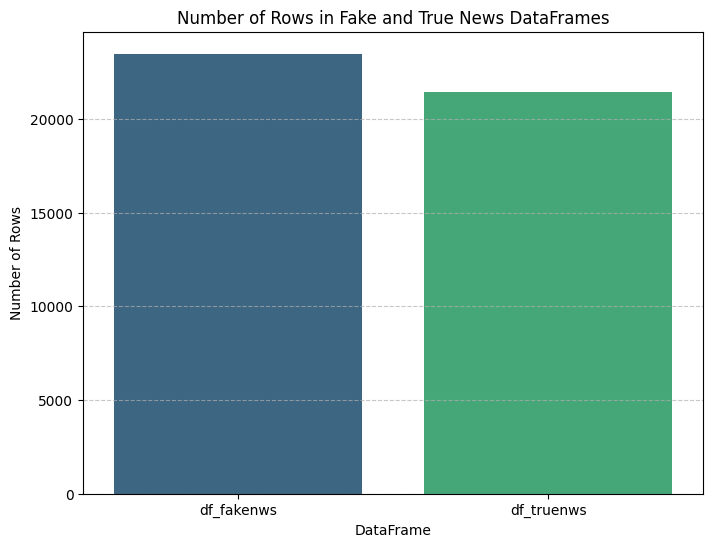

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

shapes_data = {
    'DataFrame': ['df_fakenws', 'df_truenws'],
    'Rows': [df_fakenws.shape[0], df_truenws.shape[0]]
}

df_shapes = pd.DataFrame(shapes_data)

plt.figure(figsize=(8, 6))
sns.barplot(x='DataFrame', y='Rows', data=df_shapes, palette='viridis')
plt.title('Number of Rows in Fake and True News DataFrames')
plt.ylabel('Number of Rows')
plt.xlabel('DataFrame')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [16]:
# Removing last 15 rows for manual testing
df_fake_manual_testing = df_fakenws.tail(15)
# Get the indices of the last 15 rows dynamically
indices_to_drop_fake = df_fakenws.tail(15).index
df_fakenws.drop(indices_to_drop_fake, axis=0, inplace=True)

df_true_manual_testing = df_truenws.tail(15)
# Get the indices of the last 15 rows dynamically
indices_to_drop_true = df_truenws.tail(15).index
df_truenws.drop(indices_to_drop_true, axis=0, inplace=True)

In [17]:
df_fakenws.shape, df_truenws.shape

((23451, 5), (21387, 5))

In [18]:
df_fake_manual_testing["target"] = 0
df_true_manual_testing["target"] = 1

/tmp/ipykernel_542/3121326408.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fake_manual_testing["target"] = 0
/tmp/ipykernel_542/3121326408.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_true_manual_testing["target"] = 1


In [23]:
df_true_manual_testing.head(15)

,title,text,subject,date,target
21387,Former Libyan prime minister freed after abduc...,TRIPOLI (Reuters) - Former Libyan Prime Minist...,worldnews,"August 23, 2017",1
21388,Britain outlines plans to break free of Europe...,LONDON (Reuters) - Britain on Wednesday outlin...,worldnews,"August 22, 2017",1
21389,"Trump must be respected as U.S. president, say...",BERLIN (Reuters) - Chancellor Angela Merkel sa...,worldnews,"August 23, 2017",1
21390,Pakistan rejects role of 'scapegoat for U.S. f...,"KARACHI, Pakistan (Reuters) - Pakistan has rej...",worldnews,"August 23, 2017",1
21391,Romanian president opposes plans for judicial ...,BUCHAREST (Reuters) - Romania s justice minist...,worldnews,"August 23, 2017",1
21392,"Iran, Saudi Arabia to exchange diplomatic visi...",BEIRUT (Reuters) - Iran and Saudi Arabia will ...,worldnews,"August 23, 2017",1
21393,Danish police identify torso as missing submar...,COPENHAGEN (Reuters) - Police on Wednesday ide...,worldnews,"August 23, 2017",1
21394,"Typhoon batters Hong Kong and south China, thr...","HONG KONG (Reuters) - Typhoon Hato, a maximum ...",worldnews,"August 22, 2017",1
21395,Poland to allocate additional $55 bllion on de...,WARSAW (Reuters) - Poland will allocate an add...,worldnews,"August 23, 2017",1
21396,Pro-Houthi fighters call powerful Yemen ally '...,DUBAI (Reuters) - Fighters loyal to the armed ...,worldnews,"August 23, 2017",1


In [25]:
df_fake_manual_testing.head(15)

,title,text,subject,date,target
23451,3.57 Degrees: Kevin Bacon’s Cultural Mantle Sh...,21st Century Wire says Unless you have been li...,Middle-east,"February 9, 2016",0
23452,Bernie Sanders Could End Up Winning Iowa,21st Century Wire says Iowa s Democratic Party...,Middle-east,"February 4, 2016",0
23453,Plastic Persona: Behind the Scenes of the Ted ...,21st Century Wire says Most people accept that...,Middle-east,"February 4, 2016",0
23454,‘Meet Jeb’ – Going For Your Sympathy Vote,"21st Century Wire says As Republican, Ted Cruz...",Middle-east,"February 4, 2016",0
23455,"BOILER ROOM – Examination, Exclamation, Excita...",Tune in to the Alternate Current Radio Network...,Middle-east,"February 3, 2016",0
23456,Eyewash: CIA Elites Misleading Employees Indic...,21st Century Wire says The CIA is trying its b...,Middle-east,"February 3, 2016",0
23457,Activist: ‘This is where you can make the most...,21st Century Wire says If you ve been followin...,Middle-east,"February 3, 2016",0
23458,Episode #120 – SUNDAY WIRE: ‘Crisis of Liberty...,Episode #120 of SUNDAY WIRE SHOW finally resum...,Middle-east,"January 31, 2016",0
23459,FBI Release Oregon Video Footage Depicting Dea...,21st Century Wire says..UPDATE 1-29-2016 at 01...,Middle-east,"January 29, 2016",0
23460,Trial By YouTube: Mainstream Media Use Second-...,Patrick Henningsen 21st Century WireThere exi...,Middle-east,"January 28, 2016",0


In [26]:
df_manual_testing = pd.concat([df_fake_manual_testing,df_true_manual_testing], axis = 0)
df_manual_testing.to_csv("manual_testing.csv")

In [28]:
df_merge = pd.concat([df_fakenws, df_truenws], axis =0 )
df_merge.head(10)

,title,text,subject,date,target
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


In [29]:
df_merge.columns

Index(['title', 'text', 'subject', 'date', 'target'], dtype='object')

In [30]:
df = df_merge.drop(["title", "subject","date"], axis = 1)

In [32]:
df.isnull().sum()

,0
text,0
target,0


In [34]:
df = df.sample(frac = 3, replace=True)

In [35]:
df.head()

,text,target
17224,LONDON (Reuters) - Britain said on Tuesday it ...,1
6040,Republican House Speaker Paul Ryan has been ge...,0
18004,BARCELONA (Reuters) - Catalonia s High Court h...,1
7727,DUBAI (Reuters) - Iranian President Hassan Rou...,1
3177,MOSCOW (Reuters) - Russian President Vladimir ...,1


In [42]:
df.reset_index(inplace = True)
df.drop(["index"], axis = 1, inplace = True)
df.columns


Index(['text', 'target'], dtype='object')

In [43]:
df.head()

,text,target
0,LONDON (Reuters) - Britain said on Tuesday it ...,1
1,Republican House Speaker Paul Ryan has been ge...,0
2,BARCELONA (Reuters) - Catalonia s High Court h...,1
3,DUBAI (Reuters) - Iranian President Hassan Rou...,1
4,MOSCOW (Reuters) - Russian President Vladimir ...,1


In [44]:
def wordopt(text):
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub("\\W"," ",text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

<>:3: SyntaxWarning: invalid escape sequence '\['
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\['
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_542/3432647204.py:3: SyntaxWarning: invalid escape sequence '\['
  text = re.sub('\[.*?\]', '', text)
/tmp/ipykernel_542/3432647204.py:5: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('https?://\S+|www\.\S+', '', text)
/tmp/ipykernel_542/3432647204.py:9: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub('\w*\d\w*', '', text)


In [45]:
df["text"] = df["text"].apply(wordopt)

In [46]:
x = df["text"]
y = df["target"]

In [47]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25)

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorization = TfidfVectorizer()
xv_train = vectorization.fit_transform(x_train)
xv_test = vectorization.transform(x_test)

In [49]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression()
LR.fit(xv_train,y_train)

LogisticRegression()

In [50]:
pred_lr=LR.predict(xv_test)

In [51]:
LR.score(xv_test, y_test)

0.9949745755151803

In [52]:
from sklearn.tree import DecisionTreeClassifier

DT = DecisionTreeClassifier()
DT.fit(xv_train, y_train)

DecisionTreeClassifier()

In [53]:
pred_dt = DT.predict(xv_test)

In [54]:
DT.score(xv_test, y_test)

0.9992863302506765

In [55]:
from sklearn.ensemble import GradientBoostingClassifier

GBC = GradientBoostingClassifier(random_state=0)
GBC.fit(xv_train, y_train)

GradientBoostingClassifier(random_state=0)

In [56]:
pred_gbc = GBC.predict(xv_test)

In [57]:
GBC.score(xv_test, y_test)

0.9966100686907133

In [58]:
from sklearn.ensemble import RandomForestClassifier

RFC = RandomForestClassifier(random_state=0)
RFC.fit(xv_train, y_train)

RandomForestClassifier(random_state=0)

In [59]:
pred_rfc = RFC.predict(xv_test)

In [60]:
RFC.score(xv_test, y_test)


0.9987213416991287

In [81]:
lr_accuracy = LR.score(xv_test, y_test)
dt_accuracy = DT.score(xv_test, y_test)
gbc_accuracy = GBC.score(xv_test, y_test)
rfc_accuracy = RFC.score(xv_test, y_test)

print(f"Logistic Regression Accuracy: {lr_accuracy}")
print(f"Decision Tree Accuracy: {dt_accuracy}")
print(f"Gradient Boosting Classifier Accuracy: {gbc_accuracy}")
print(f"Random Forest Classifier Accuracy: {rfc_accuracy}")

Logistic Regression Accuracy: 0.9949745755151803
Decision Tree Accuracy: 0.9992863302506765
Gradient Boosting Classifier Accuracy: 0.9966100686907133
Random Forest Classifier Accuracy: 0.9987213416991287


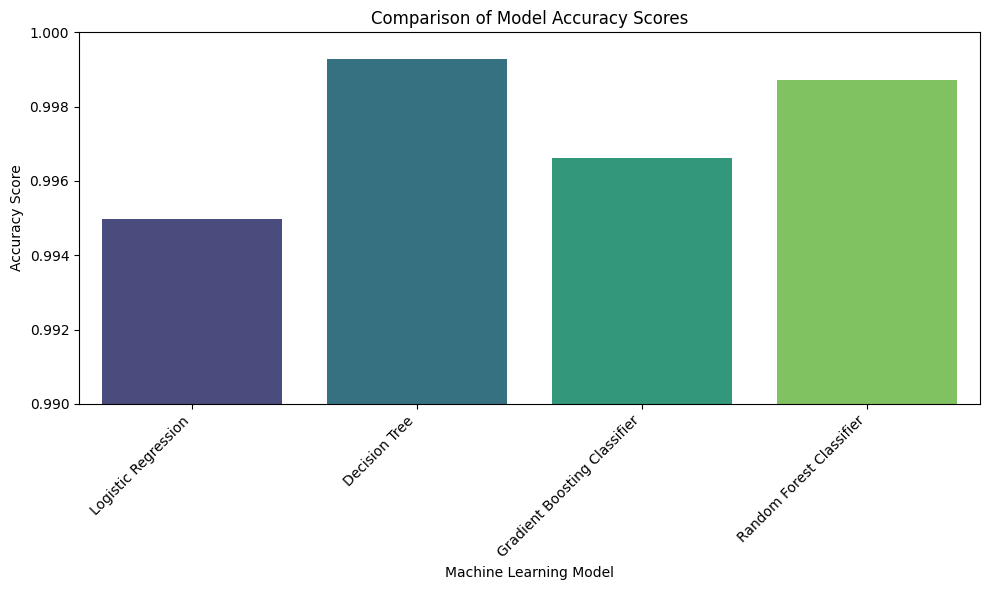

In [84]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, hue='Model', palette='viridis', legend=False)
plt.title('Comparison of Model Accuracy Scores')
plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy Score')
plt.ylim(0.99, 1.0) # Set y-axis limits for better visualization of small differences
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [88]:
def output_lable(n):
    if n == 0:
        return "Fake News"
    elif n == 1:
        return "Not A Fake News"

def manual_testing(news):
    testing_news = {"text":[news]}
    new_def_test = pd.DataFrame(testing_news)
    new_def_test["text"] = new_def_test["text"].apply(wordopt)
    new_x_test = new_def_test["text"]
    new_xv_test = vectorization.transform(new_x_test)

    pred_LR = LR.predict(new_xv_test)
    pred_DT = DT.predict(new_xv_test)
    pred_GBC = GBC.predict(new_xv_test)
    pred_RFC = RFC.predict(new_xv_test)

    # Calculate majority vote
    predictions = [pred_LR[0], pred_DT[0], pred_GBC[0], pred_RFC[0]]
    fake_count = predictions.count(0)
    true_count = predictions.count(1)

    if fake_count > true_count:
        final_verdict = "It is a Fake News"
    else:
        final_verdict = "It is not a Fake News"

    return print(

        f"{final_verdict}"
    )


In [76]:
news = input("Enter the news article to test: ")
manual_testing(news)

Enter the news article to test: 21st Century Wire says Al Jazeera America will go down in history as one of the biggest failures in broadcast media history.Ever since the US and its allies began plotting to overthrow Libya and Syria, Al Jazeera has deteriorated from a promising international news network in 2003   into what it has become in 2016   a full-blown agit prop media shop for the US State Department and the Pentagon. In fact, US Military Central Command (CENTCOM) for the Middle East region is located in Qatar s capital of Doha, conveniently located just down the road from Al Jazeera s headquarters. Nice and cozy.Al Jazeera s role in promoting  regime change  and the destablization of Syria is now recorded history, as are its many shameful exhibitions of media fakery.The Qatari royals tried to expand propaganda operations into North America, but no matter how much money they threw at it (and those royals just love throwing money at things to try and get them to work), no one ca

In [80]:
news = input("Enter the news article to test: ")
manual_testing(news)

Enter the news article to test: WASHINGTON (Reuters) - Legislation to provide $81 billion in new disaster aid for U.S. states, Puerto Rico and the U.S. Virgin Islands was put on hold by the Senate on Thursday amid attacks from both Republicans and Democrats. The Republican-controlled House of Representatives passed the legislation earlier on Thursday to help recovery efforts stemming from hurricanes and wildfires. But the Senate put off a vote until at least January, according to some lawmakers and aides, after Democrats complained Puerto Rico was not getting enough help and some fiscal hawks fretted about the overall cost. 
It is not a Fake News


In [89]:
news = input("Enter the news article to test: ")
manual_testing(news)


Enter the news article to test: (Reuters) - Democrat Doug Jonesâ€™ surprise victory over Republican Roy Moore in this monthâ€™s special U.S. Senate election will be certified on Dec. 28, Alabama state officials said on Friday. Jones will be the first Democrat sent to the Senate from Republican stronghold Alabama in a quarter century. When he takes office, Republicansâ€™ majority in the chamber will narrow to 51 of the 100 seats. Alabama Governor Kay Ivey, Attorney General Steve Marshall and Secretary of State John Merrill will meet to certify Jonesâ€™ win, Merrillâ€™s office said in a statement. Jonesâ€™ margin of victory was 1.5 percentage points. Moore has not conceded defeat in the Dec. 12 vote, despite being urged by President Donald Trump to do so. Calls and emails to Mooreâ€™s campaign spokeswomen were not immediately returned on Friday. Moore was a controversial candidate whose campaign was beset by allegations that he sexually assaulted or pursued teenage girls while he was in 

In [90]:
news = input("Enter the news article to test: ")
manual_testing(news)


Enter the news article to test: Over the last few weeks, I ve watched as the last shreds of the Republican Party s  family values  rotted away.As Alabama voters prepare to go to the polls in December they have two choices before them.They can vote for the Democrat and prove that they refuse to tolerate an accused child molester and sexual predator being in their party and in the Senate, or they can put political power over the morality they have long preached about.In other words, they can either put power over principles or put principles over power.They can t do both.And while they are damned if they do and damned if they don t, choosing the latter of those two options would be a far better and more honorable choice.Some things go above politics, and sexual assault is, and rightfully should, be one of them.Voting for Moore for the sake of political power throws every sexual assault victim under the bus. It will especially be a slap in the face of women across the country, a major vot